In [27]:
scale_pos_weight_v2 = y2_train.value_counts()[0] / y2_train.value_counts()[1]

# ---- XGBoost v2 ----
xgb_model_v2 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight_v2,
    eval_metric='logloss',
    random_state=42
)
xgb_model_v2.fit(X2_train, y2_train)

xgb_pred_v2 = xgb_model_v2.predict(X2_test)
xgb_proba_v2 = xgb_model_v2.predict_proba(X2_test)[:, 1]

print("=== XGBoost v2 (23 features) ===")
print("Accuracy:", accuracy_score(y2_test, xgb_pred_v2))
print("AUC-ROC:", roc_auc_score(y2_test, xgb_proba_v2))
print("\n", classification_report(y2_test, xgb_pred_v2))

# ---- Random Forest v2 ----
rf_model_v2 = RandomForestClassifier(
    n_estimators=300,
    max_depth=12,
    class_weight='balanced',
    random_state=42
)
rf_model_v2.fit(X2_train, y2_train)

rf_pred_v2 = rf_model_v2.predict(X2_test)
rf_proba_v2 = rf_model_v2.predict_proba(X2_test)[:, 1]

print("\n=== Random Forest v2 (23 features) ===")
print("Accuracy:", accuracy_score(y2_test, rf_pred_v2))
print("AUC-ROC:", roc_auc_score(y2_test, rf_proba_v2))
print("\n", classification_report(y2_test, rf_pred_v2))

# ---- Ensemble v2 ----
ensemble_proba_v2 = (xgb_proba_v2 + rf_proba_v2) / 2
ensemble_pred_v2 = (ensemble_proba_v2 >= 0.5).astype(int)

print("\n=== Ensemble v2 (23 features) ===")
print("Accuracy:", accuracy_score(y2_test, ensemble_pred_v2))
print("AUC-ROC:", roc_auc_score(y2_test, ensemble_proba_v2))
print("\n", classification_report(y2_test, ensemble_pred_v2))


=== XGBoost v2 (23 features) ===
Accuracy: 0.8894389438943895
AUC-ROC: 0.8877199578884042

               precision    recall  f1-score   support

           0       0.96      0.91      0.94      1090
           1       0.47      0.69      0.56       122

    accuracy                           0.89      1212
   macro avg       0.71      0.80      0.75      1212
weighted avg       0.91      0.89      0.90      1212


=== Random Forest v2 (23 features) ===
Accuracy: 0.9034653465346535
AUC-ROC: 0.8835238381711537

               precision    recall  f1-score   support

           0       0.94      0.95      0.95      1090
           1       0.52      0.45      0.48       122

    accuracy                           0.90      1212
   macro avg       0.73      0.70      0.72      1212
weighted avg       0.90      0.90      0.90      1212


=== Ensemble v2 (23 features) ===
Accuracy: 0.9051155115511551
AUC-ROC: 0.889344262295082

               precision    recall  f1-score   support

       

In [28]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# XGBoost tuning
xgb_param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.03, 0.05, 0.1],
    'min_child_weight': [1, 3, 5]
}

xgb_search = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight_v2, eval_metric='logloss', random_state=42),
    xgb_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
xgb_search.fit(X2_train, y2_train)

print("Best XGBoost params:", xgb_search.best_params_)
print("Best CV AUC-ROC:", xgb_search.best_score_)

xgb_best = xgb_search.best_estimator_
xgb_best_pred = xgb_best.predict(X2_test)
xgb_best_proba = xgb_best.predict_proba(X2_test)[:, 1]

print("\n=== Tuned XGBoost — Test Set ===")
print("Accuracy:", accuracy_score(y2_test, xgb_best_pred))
print("AUC-ROC:", roc_auc_score(y2_test, xgb_best_proba))
print("\n", classification_report(y2_test, xgb_best_pred))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best XGBoost params: {'learning_rate': 0.03, 'max_depth': 4, 'min_child_weight': 5, 'n_estimators': 200}
Best CV AUC-ROC: 0.8943846473118342

=== Tuned XGBoost — Test Set ===
Accuracy: 0.8498349834983498
AUC-ROC: 0.9022484584147993

               precision    recall  f1-score   support

           0       0.98      0.85      0.91      1090
           1       0.38      0.82      0.52       122

    accuracy                           0.85      1212
   macro avg       0.68      0.84      0.72      1212
weighted avg       0.92      0.85      0.87      1212



In [29]:
rf_param_grid = {
    'n_estimators': [200, 300, 400],
    'max_depth': [8, 10, 12],
    'min_samples_split': [5, 10, 15],
    'min_samples_leaf': [2, 4, 6]
}

rf_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    rf_param_grid,
    cv=cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
rf_search.fit(X2_train, y2_train)

print("Best Random Forest params:", rf_search.best_params_)
print("Best CV AUC-ROC:", rf_search.best_score_)

rf_best = rf_search.best_estimator_
rf_best_pred = rf_best.predict(X2_test)
rf_best_proba = rf_best.predict_proba(X2_test)[:, 1]

print("\n=== Tuned Random Forest — Test Set ===")
print("Accuracy:", accuracy_score(y2_test, rf_best_pred))
print("AUC-ROC:", roc_auc_score(y2_test, rf_best_proba))
print("\n", classification_report(y2_test, rf_best_pred))

# Tuned ensemble
final_ensemble_proba = (xgb_best_proba + rf_best_proba) / 2
final_ensemble_pred = (final_ensemble_proba >= 0.5).astype(int)

print("\n=== Final Tuned Ensemble ===")
print("Accuracy:", accuracy_score(y2_test, final_ensemble_pred))
print("AUC-ROC:", roc_auc_score(y2_test, final_ensemble_proba))
print("\n", classification_report(y2_test, final_ensemble_pred))

Fitting 5 folds for each of 81 candidates, totalling 405 fits
Best Random Forest params: {'max_depth': 12, 'min_samples_leaf': 6, 'min_samples_split': 5, 'n_estimators': 200}
Best CV AUC-ROC: 0.8997832256634952

=== Tuned Random Forest — Test Set ===
Accuracy: 0.8836633663366337
AUC-ROC: 0.8940366972477063

               precision    recall  f1-score   support

           0       0.96      0.91      0.93      1090
           1       0.45      0.68      0.54       122

    accuracy                           0.88      1212
   macro avg       0.71      0.79      0.74      1212
weighted avg       0.91      0.88      0.89      1212


=== Final Tuned Ensemble ===
Accuracy: 0.8663366336633663
AUC-ROC: 0.9010452699654083

               precision    recall  f1-score   support

           0       0.97      0.88      0.92      1090
           1       0.41      0.75      0.53       122

    accuracy                           0.87      1212
   macro avg       0.69      0.81      0.73      1212
we

In [30]:
from sklearn.metrics import precision_recall_curve

# Find the threshold that maximizes accuracy while keeping decent recall
thresholds_to_test = np.arange(0.3, 0.7, 0.02)
results = []

for t in thresholds_to_test:
    pred_t = (xgb_best_proba >= t).astype(int)
    acc = accuracy_score(y2_test, pred_t)
    from sklearn.metrics import recall_score, precision_score
    rec = recall_score(y2_test, pred_t)
    prec = precision_score(y2_test, pred_t)
    results.append({'threshold': round(t,2), 'accuracy': round(acc,4), 'recall': round(rec,4), 'precision': round(prec,4)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

 threshold  accuracy  recall  precision
      0.30    0.7706  0.8607     0.2869
      0.32    0.7781  0.8443     0.2918
      0.34    0.7863  0.8443     0.3003
      0.36    0.7979  0.8443     0.3131
      0.38    0.8036  0.8443     0.3199
      0.40    0.8102  0.8361     0.3269
      0.42    0.8218  0.8361     0.3423
      0.44    0.8267  0.8361     0.3493
      0.46    0.8342  0.8279     0.3594
      0.48    0.8449  0.8197     0.3759
      0.50    0.8498  0.8197     0.3846
      0.52    0.8581  0.7951     0.3975
      0.54    0.8622  0.7869     0.4051
      0.56    0.8713  0.7787     0.4241
      0.58    0.8746  0.7459     0.4292
      0.60    0.8779  0.7377     0.4369
      0.62    0.8837  0.7377     0.4523
      0.64    0.8853  0.7377     0.4569
      0.66    0.8911  0.7295     0.4734
      0.68    0.8944  0.7131     0.4833


In [31]:
FINAL_THRESHOLD = 0.56

final_pred = (xgb_best_proba >= FINAL_THRESHOLD).astype(int)

print("=== FINAL CLINICAL MODEL — Tuned XGBoost @ threshold 0.56 ===")
print("Accuracy:", accuracy_score(y2_test, final_pred))
print("AUC-ROC:", roc_auc_score(y2_test, xgb_best_proba))
print("\n", classification_report(y2_test, final_pred))

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y2_test, final_pred)
print("\nConfusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {cm[0][0]} | False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]} | True Positives: {cm[1][1]}")

=== FINAL CLINICAL MODEL — Tuned XGBoost @ threshold 0.56 ===
Accuracy: 0.8712871287128713
AUC-ROC: 0.9022484584147993

               precision    recall  f1-score   support

           0       0.97      0.88      0.92      1090
           1       0.42      0.78      0.55       122

    accuracy                           0.87      1212
   macro avg       0.70      0.83      0.74      1212
weighted avg       0.92      0.87      0.89      1212


Confusion Matrix:
[[961 129]
 [ 27  95]]

True Negatives: 961 | False Positives: 129
False Negatives: 27 | True Positives: 95


In [32]:
import joblib

MODEL_PATH = '/content/drive/MyDrive/DR_Project/models'
import os
os.makedirs(MODEL_PATH, exist_ok=True)

joblib.dump(xgb_best, f'{MODEL_PATH}/clinical_model_xgboost.pkl')
joblib.dump(FINAL_THRESHOLD, f'{MODEL_PATH}/clinical_threshold.pkl')

print("Model 1 (clinical) saved to Drive.")

Model 1 (clinical) saved to Drive.


In [33]:
!pip install imbalanced-learn -q

from imblearn.over_sampling import SMOTE

# Apply SMOTE only to training data (never touch the test set)
smote = SMOTE(random_state=42, k_neighbors=5)
X2_train_smote, y2_train_smote = smote.fit_resample(X2_train, y2_train)

print("Before SMOTE:", y2_train.value_counts().to_dict())
print("After SMOTE:", y2_train_smote.value_counts().to_dict())

Before SMOTE: {0: 4356, 1: 488}
After SMOTE: {0: 4356, 1: 4356}


In [34]:
xgb_smote = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.03,
    min_child_weight=5,
    eval_metric='logloss',
    random_state=42
    # note: no scale_pos_weight needed now — SMOTE already balanced the classes
)
xgb_smote.fit(X2_train_smote, y2_train_smote)

xgb_smote_proba = xgb_smote.predict_proba(X2_test)[:, 1]
xgb_smote_pred_default = (xgb_smote_proba >= 0.5).astype(int)

print("=== XGBoost + SMOTE (threshold 0.5) ===")
print("Accuracy:", accuracy_score(y2_test, xgb_smote_pred_default))
print("AUC-ROC:", roc_auc_score(y2_test, xgb_smote_proba))
print("\n", classification_report(y2_test, xgb_smote_pred_default))

=== XGBoost + SMOTE (threshold 0.5) ===
Accuracy: 0.8671617161716172
AUC-ROC: 0.8877537975635433

               precision    recall  f1-score   support

           0       0.97      0.88      0.92      1090
           1       0.41      0.72      0.52       122

    accuracy                           0.87      1212
   macro avg       0.69      0.80      0.72      1212
weighted avg       0.91      0.87      0.88      1212



SHAP values computed: (1212, 23)


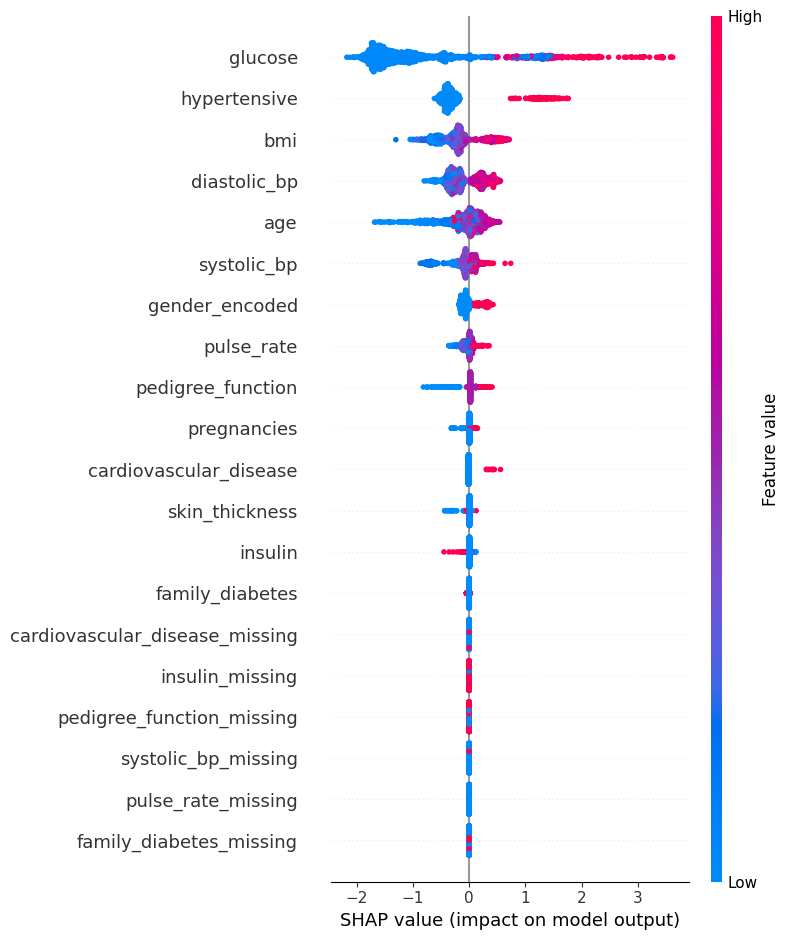

In [35]:
import shap

explainer = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X2_test)

print("SHAP values computed:", shap_values.shape)

import matplotlib.pyplot as plt
shap.summary_plot(shap_values, X2_test, feature_names=feature_cols_v2, show=False)
plt.tight_layout()
plt.savefig('/content/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
import shutil
shutil.copy('/content/shap_summary.png', '/content/drive/MyDrive/DR_Project/models/shap_summary.png')
print("SHAP chart saved to Drive.")

SHAP chart saved to Drive.


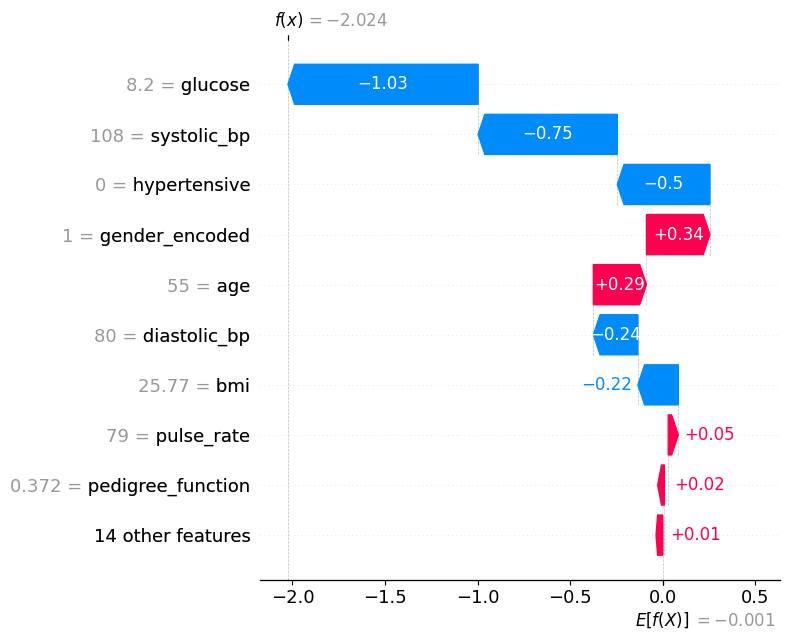

In [37]:
patient_index = 0

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[patient_index],
        base_values=explainer.expected_value,
        data=X2_test.iloc[patient_index],
        feature_names=feature_cols_v2
    ),
    show=False
)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/DR_Project/models/shap_waterfall_patient1.png', dpi=150, bbox_inches='tight')
plt.show()